# Stage 5: Basic Fraud Modelling
This notebook fulfills the final practical deliverable for our study path. We will handle missing values, combat class imbalance, perform a time-based train/test split, and evaluate our models using a confusion matrix.

## 1. Load Data and Impute Missing Values

In [1]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Load the dataset
df = pd.read_csv('training_dataset.csv')
print("Original Dataset Shape:", df.shape)
display(df.head(50))
display(df.all)

# Impute missing values in 'transaction_amount' using the median
imputer = SimpleImputer(strategy='median')
df['transaction_amount'] = imputer.fit_transform(df[['transaction_amount']])
print("\nMissing values after imputation:\n", df.isnull().sum())
display(df.head(50))


Original Dataset Shape: (500, 6)


,transaction_id,transaction_amount,customer_risk_score,days_since_signup,previous_transaction_count,is_fraud
0,489,188.94,0.04,10,0,0
1,47,45.35,0.25,3,0,0
2,110,58.05,0.04,4,0,0
3,430,258.21,0.10,15,0,0
4,324,37.11,0.25,30,1,0
5,86,84.25,0.24,10,0,0
6,336,69.35,0.25,55,2,0
7,335,180.91,0.09,70,0,0
8,280,365.05,0.02,82,0,0
9,28,49.92,0.01,1,0,0


<bound method DataFrame.all of      transaction_id  transaction_amount  customer_risk_score  \
0               489              188.94                 0.04   
1                47               45.35                 0.25   
2               110               58.05                 0.04   
3               430              258.21                 0.10   
4               324               37.11                 0.25   
..              ...                 ...                  ...   
495               4              474.92                 0.00   
496              89             2731.39                 0.94   
497             449              497.34                 0.25   
498             281              180.55                 0.00   
499             484              146.70                 0.27   

     days_since_signup  previous_transaction_count  is_fraud  
0                   10                           0         0  
1                    3                           0         0  
2          


Missing values after imputation:
 transaction_id                0
transaction_amount            0
customer_risk_score           0
days_since_signup             0
previous_transaction_count    0
is_fraud                      0
dtype: int64


,transaction_id,transaction_amount,customer_risk_score,days_since_signup,previous_transaction_count,is_fraud
0,489,188.94,0.04,10,0,0
1,47,45.35,0.25,3,0,0
2,110,58.05,0.04,4,0,0
3,430,258.21,0.10,15,0,0
4,324,37.11,0.25,30,1,0
5,86,84.25,0.24,10,0,0
6,336,69.35,0.25,55,2,0
7,335,180.91,0.09,70,0,0
8,280,365.05,0.02,82,0,0
9,28,49.92,0.01,1,0,0


# 1.5 Learning how to draw bar plot graph
## krishna is also learning
we are moving forward

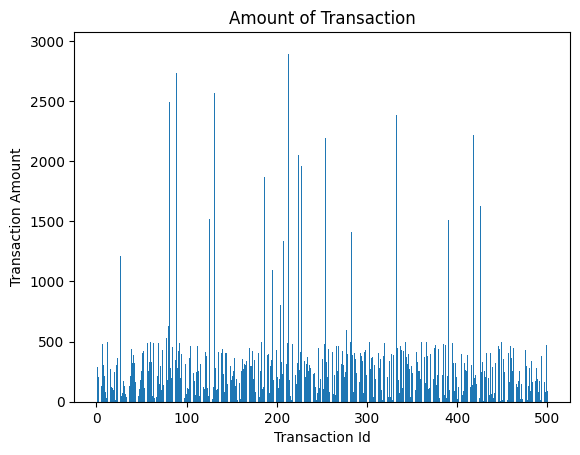

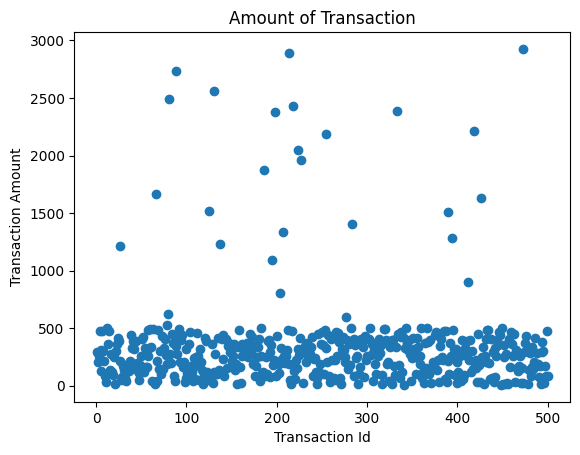

In [2]:
#display(df.all)
import matplotlib.pyplot as plt
plt.bar(df['transaction_id'], df['transaction_amount'])

plt.xlabel('Transaction Id')
plt.ylabel('Transaction Amount')
plt.title('Amount of Transaction')

plt.show()
plt.scatter(df['transaction_id'], df['transaction_amount'])

plt.xlabel('Transaction Id')
plt.ylabel('Transaction Amount')
plt.title('Amount of Transaction')
plt.show()

## 2. Feature Selection & Time-Based Split
To prevent data leakage, we cannot shuffle the data before splitting. We must simulate the real world where we train on the past and predict on the future.

In [3]:
# Drop transaction_id as it has no predictive power
X = df.drop(columns=['transaction_id', 'is_fraud'])
y = df['is_fraud']

# Perform a strictly sequential split (no shuffling)
# First 70% as training, last 30% as test
split_index = int(len(df) * 0.7)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])


Training set size: 350
Testing set size: 150


## 3. Train Baseline Logistic Regression Model
We use `class_weight='balanced'` because fraud is rare, so the model needs to penalize missing a fraudster much more heavily than a normal prediction.

--- Logistic Regression Evaluation ---
              precision    recall  f1-score   support

           0       0.98      0.75      0.85       146
           1       0.05      0.50      0.10         4

    accuracy                           0.75       150
   macro avg       0.52      0.63      0.47       150
weighted avg       0.96      0.75      0.83       150



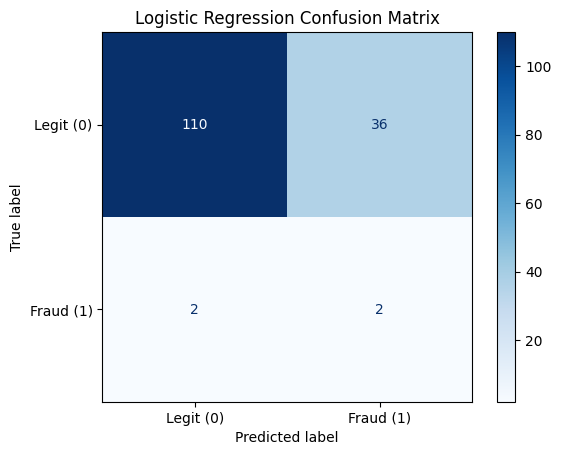

Accuracy Score: 0.7466666666666667
ROC AUC Score: 0.5873287671232876
FPR: [0.         0.00684932 0.13013699 0.13013699 0.56849315 0.56849315
 0.82191781 0.82191781 1.        ]
TPR: [0.   0.   0.   0.5  0.5  0.75 0.75 1.   1.  ]
Thresholds: [           inf 7.76299564e-01 6.98952229e-01 6.81181076e-01
 3.64383145e-01 3.41908485e-01 1.55919090e-01 1.55758842e-01
 2.90906864e-04]


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train the model using the 'liblinear' solver
#solver = HOW Logistic Regression learns.
#liblinear = one learning/optimization method, often handy for small binary classification.
#I want to change threshold below ?
log_reg = LogisticRegression(class_weight='balanced', random_state=42, solver='liblinear')
log_reg.fit(X_train_scaled, y_train)

# 3. Predict on the test set
#y_pred_log = log_reg.predict(X_test_scaled)

# 3. Predict PROBABILITIES instead of hard classes
y_pred_probs = log_reg.predict_proba(X_test_scaled)[:, 1] # Get the probability of Fraud (class 1)
# 4. Apply a Custom Decision Threshold (e.g., 85% instead of 50%)
custom_threshold = 0.60   
#i can change the threshold pecentage here above
y_pred_log_custom = (y_pred_probs >= custom_threshold).astype(int)

# Output evaluation metrics
print("--- Logistic Regression Evaluation ---")
print(classification_report(y_test, y_pred_log_custom, zero_division=0))

# Plot Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log_custom)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['Legit (0)', 'Fraud (1)'])
disp_log.plot(cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
print('Accuracy Score:', accuracy_score(y_test, y_pred_log_custom))
print('ROC AUC Score:', roc_auc_score(y_test, y_pred_probs))
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
print('FPR:', fpr)
print('TPR:', tpr)
print('Thresholds:', thresholds)


## 4. Train Tree Model (Random Forest)
Tree models often capture non-linear relationships better than linear models.

--- Random Forest Evaluation ---
              precision    recall  f1-score   support

           0       0.97      0.71      0.82       146
           1       0.02      0.25      0.04         4

    accuracy                           0.70       150
   macro avg       0.50      0.48      0.43       150
weighted avg       0.95      0.70      0.80       150



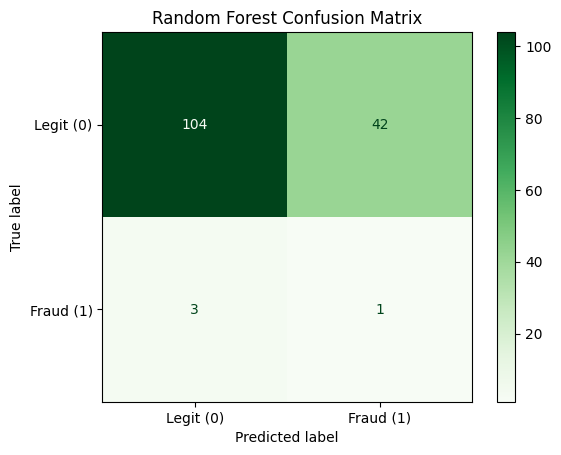

Accuracy Score: 0.7
ROC AUC Score: 0.5881849315068494
FPR: [0.         0.00684932 0.06164384 0.07534247 0.08219178 0.09589041
 0.10273973 0.11643836 0.14383562 0.15753425 0.16438356 0.18493151
 0.2260274  0.25342466 0.28767123 0.31506849 0.36986301 0.45890411
 0.57534247 1.        ]
TPR: [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.25 0.25 0.25
 0.25 0.25 0.75 0.75 0.75 1.  ]
Thresholds: [ inf 0.43 0.18 0.17 0.16 0.14 0.13 0.12 0.11 0.1  0.09 0.08 0.07 0.06
 0.05 0.04 0.03 0.02 0.01 0.  ]


In [5]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predict on the test set
#y_pred_rf = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test_scaled)[:,1]
# Lower the threshold to 5% to aggressively catch more fraud (at 5% threshold it catches one fraud)
custom_threshold = 0.05
y_pred_rf_custom = (rf_probs >= custom_threshold).astype(int)

# Output evaluation metrics
print("--- Random Forest Evaluation ---")
#print(classification_report(y_test, y_pred_rf, zero_division=0))
print(classification_report(y_test, y_pred_rf_custom, zero_division=0))

# Plot Confusion Matrix
#cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_rf = confusion_matrix(y_test, y_pred_rf_custom)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Legit (0)', 'Fraud (1)'])
disp_rf.plot(cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()

from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
print('Accuracy Score:', accuracy_score(y_test, y_pred_rf_custom))
print('ROC AUC Score:', roc_auc_score(y_test, rf_probs))
fpr, tpr, thresholds = roc_curve(y_test, rf_probs)
print('FPR:', fpr)
print('TPR:', tpr)
print('Thresholds:', thresholds)
